# NeuroWorkflow: Single Cell — Point Neuron

Single `iaf_psc_alpha` neuron driven by a somatic current clamp, simulated
with BMTK PointNet (NEST).

```
NW_IClamp → NW_Population → NW_SimConfig → NW_Analysis
```

- **NW_IClamp** — somatic current clamp stimulus
- **NW_Population** — builds SONATA network files via BMTK NetworkBuilder
- **NW_SimConfig** — generates SONATA config and runs the simulation (PointNet or BioNet)
- **NW_Analysis** — spike raster and membrane potential traces

In [1]:
from neuroworkflow import WorkflowBuilder
from neuroworkflow.nodes.network.NW_Population   import NW_Population
from neuroworkflow.nodes.simulation.NW_SimConfig import NW_SimConfig
from neuroworkflow.nodes.analysis.NW_Analysis    import NW_Analysis
from neuroworkflow.nodes.stimulus.NW_IClamp      import NW_IClamp

## 1. Instantiate nodes

In [2]:
pop   = NW_Population("Population")
cfg   = NW_SimConfig("SimConfig")
ana   = NW_Analysis("Analysis")
clamp = NW_IClamp("IClamp")

print(pop.get_info())

{'name': 'Population', 'type': 'nw_population', 'description': "Creates a BMTK NetworkBuilder population and passes the live builder object to NW_Connectivity (for inter-population edges) or directly to NW_SimConfig. build() and save() are called by NW_SimConfig, following BMTK's own sequence.", 'parameters': {'pop_name': 'v1', 'N': 1, 'ei_type': 'exc', 'location': 'VISp', 'layer': 'L4', 'model_type': 'point_neuron', 'model_template': 'nest:iaf_psc_alpha', 'nest_params': {'C_m': 250.0, 'tau_m': 10.0, 't_ref': 2.0, 'V_th': -55.0, 'V_reset': -70.0, 'E_L': -70.0}, 'dynamics_params_file': '', 'model_processing': '', 'morphology': '', 'mechanisms_source': '', 'hoc_template': ''}, 'optimizable_parameters': {}, 'input_ports': {'iclamp': {'type': 'dict', 'description': 'Current clamp dict from NW_IClamp (keys: amp, delay, duration). Passed through to NW_SimConfig via the population output.', 'optional': True}}, 'output_ports': {'population': {'type': 'object', 'description': 'Dict with: builde

In [3]:
pop._parameters

{'pop_name': 'v1',
 'N': 1,
 'ei_type': 'exc',
 'location': 'VISp',
 'layer': 'L4',
 'model_type': 'point_neuron',
 'model_template': 'nest:iaf_psc_alpha',
 'nest_params': {'C_m': 250.0,
  'tau_m': 10.0,
  't_ref': 2.0,
  'V_th': -55.0,
  'V_reset': -70.0,
  'E_L': -70.0},
 'dynamics_params_file': '',
 'model_processing': '',
 'morphology': '',
 'mechanisms_source': '',
 'hoc_template': ''}

## Exploring a node with the Neuro-Workflow API

Every Neuro-Workflow node is **self-describing**. Before configuring or running
anything, you can inspect its parameters, input/output ports, methods, execution
steps, and the underlying schema (`NODE_DEFINITION`). The same calls work on any
node (`pop`, `clamp`, `cfg`, `ana`, …) — here we explore the `Population` node.

In [4]:
# Parameters and their current values (these are the defaults until you call configure())
for name, value in pop.get_info()['parameters'].items():
    print(f"{name:24s} = {value!r}")

pop_name                 = 'v1'
N                        = 1
ei_type                  = 'exc'
location                 = 'VISp'
layer                    = 'L4'
model_type               = 'point_neuron'
model_template           = 'nest:iaf_psc_alpha'
nest_params              = {'C_m': 250.0, 'tau_m': 10.0, 't_ref': 2.0, 'V_th': -55.0, 'V_reset': -70.0, 'E_L': -70.0}
dynamics_params_file     = ''
model_processing         = ''
morphology               = ''
mechanisms_source        = ''
hoc_template             = ''


In [5]:
# Input ports (what the node consumes) and output ports (what it produces),
# with their data type and a scientific description.
for name, info in pop.get_info()['input_ports'].items():
    print(f"[in]  {name:14s} ({info['type']}, optional={info['optional']}) -- {info['description']}")

for name, info in pop.get_info()['output_ports'].items():
    print(f"[out] {name:14s} ({info['type']}) -- {info['description']}")

[in]  iclamp         (dict, optional=True) -- Current clamp dict from NW_IClamp (keys: amp, delay, duration). Passed through to NW_SimConfig via the population output.
[out] population     (object) -- Dict with: builder (live NetworkBuilder), pop_name (str), network_dir (str), and optionally current_clamp (dict). Consumed by NW_Connectivity or NW_SimConfig.


In [6]:
# Methods the node exposes (from its schema) and what each one does.
for name, description in pop.get_info()['methods'].items():
    print(f"{name}: {description}")

build: Create NetworkBuilder, add nodes, resolve dynamics params, copy biophysical source files. Does not call net.build() or net.save() — that is NW_SimConfig's responsibility.


In [7]:
# Process steps: the order the methods run in, and which ports each reads / writes.
for step in pop.get_info()['process_steps']:
    print(f"{step['name']:10s} inputs={step['inputs']} -> outputs={step['outputs']}")

build      inputs=['iclamp'] -> outputs=['population']


In [8]:
# The schema itself (NODE_DEFINITION): the stage in the pipeline, the simulator/tool,
# the source model it implements, and a one-line scientific description.
schema = NW_Population.NODE_DEFINITION
print('type        :', schema.type)
print('stage       :', schema.stage)
print('tool        :', schema.tool)
print('model_source:', schema.model_source)
print('description :', schema.description)

type        : nw_population
stage       : population
tool        : BMTK
model_source: https://alleninstitute.github.io/bmtk/
description : Creates a BMTK NetworkBuilder population and passes the live builder object to NW_Connectivity (for inter-population edges) or directly to NW_SimConfig. build() and save() are called by NW_SimConfig, following BMTK's own sequence.


In [ ]:
# Read a single port's value through its accessor.
# NOTE: port values are None until the workflow is built and executed (Section 3).
# Re-run this cell after running the workflow to see the populated values.
print('output port "population":', pop.get_output_port('population').value)
print('input  port "iclamp"   :', pop.get_input_port('iclamp').get_value())

## 2. Configure nodes

Neuron model parameters are written to `components/point_neuron_models/pop_name_params.json`
at runtime by the Population node.  
To use an existing file (e.g. an Allen GLIF JSON), drop it into `components/point_neuron_models/`
and set `dynamics_params_file='filename.json'` (filename only, no path).

In [5]:
pop.configure(
    pop_name       = "v1",
    N              = 1,
    model_type     = "point_neuron",
    model_template = "nest:iaf_psc_alpha",
    ei_type        = "exc",
    location       = "VISp",
    layer          = "L4",
    nest_params = {
        "C_m":     250.0,   # pF  membrane capacitance
        "tau_m":   10.0,    # ms  membrane time constant
        "t_ref":   2.0,     # ms  refractory period
        "V_th":    -55.0,   # mV  spike threshold
        "V_reset": -70.0,   # mV  reset potential
        "E_L":     -70.0,   # mV  resting potential
    },
)

clamp.configure(
    amp_na      = 0.150,
    delay_ms    = 500.0,
    duration_ms = 2000.0,
)

cfg.configure(
    simulator          = "pointnet",
    config_file        = "config_pointneuron.json",
    tstop_ms           = 3000.0,
    dt_ms              = 0.1,
    # PointNet/NEST uses V_m; BioNet/NEURON uses v.
    # cells: "all", a pop name ("v1"), a filter {"ei_type": "exc"}, or node ids [0,1,2]
    reports = {
        "v_report": {
            "variable_name": "V_m",
            "cells":         "all",
            "module":        "membrane_report",
            "sections":      "soma",
        }
    },
    compile_mechanisms = False,
    overwrite          = True,
)

ana.configure(
    plot_raster    = True,
    with_histogram = False,
    plot_traces    = True,
    report_name    = "v_report",
    save_figures   = True,
)

In [6]:
cfg._parameters

{'simulator': 'pointnet',
 'config_file': 'config_pointneuron.json',
 'tstop_ms': 3000.0,
 'dt_ms': 0.1,
 'reports': {'v_report': {'variable_name': 'V_m',
   'cells': 'all',
   'module': 'membrane_report',
   'sections': 'soma'}},
 'compile_mechanisms': False,
 'overwrite': True}

## 3. Build and run the workflow

Executing node: IClamp
Executing node: Population
Executing node: SimConfig



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Mar  4 2025 17:27:39

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-06-17 14:20:10,819 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:20:10,854 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


...

2026-06-17 14:20:10,893 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:20:10,913 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis
[NW_Analysis] plot_raster skipped: Could not fine spikes file with node population "v1".


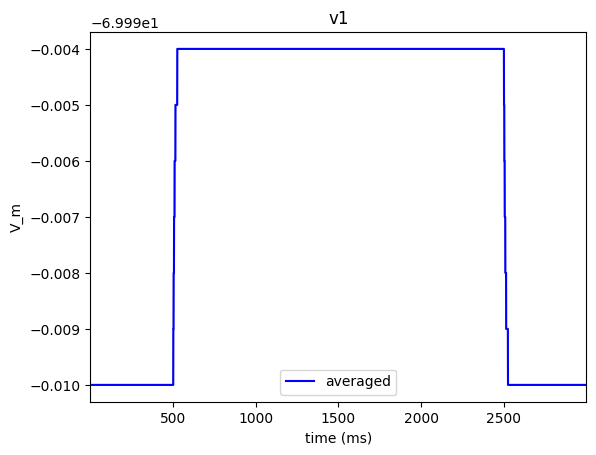

Workflow completed successfully


In [7]:
wf = WorkflowBuilder("NW_SingleCell_PointNeuron")
wf.add_node(clamp)
wf.add_node(pop)
wf.add_node(cfg)
wf.add_node(ana)

wf.connect("IClamp",     "iclamp",      "Population", "iclamp")
wf.connect("Population", "population",  "SimConfig",  "populations")
wf.connect("SimConfig",  "results",     "Analysis",   "results")

wf.context["results_path"] = "./results/run1"

workflow = wf.build()
ok = workflow.execute()
assert ok, "Workflow failed — check printed errors above"
print("Workflow completed successfully")


## Exploring the built workflow

Once built, the `workflow` object is also self-describing: you can inspect how
many nodes and connections (edges) it has, list the wiring, check the execution
order, and validate the graph before (or after) running it.

In [ ]:
# How many nodes and connections (edges) does the workflow have?
print('nodes      :', len(workflow.nodes), '->', list(workflow.nodes))
print('connections:', len(workflow.connections), 'edges')

In [ ]:
# List every connection (edge): source node.port  ->  target node.port
for c in workflow.connections:
    print(f"{c.from_node}.{c.from_port}  ->  {c.to_node}.{c.to_port}")

In [ ]:
# Execution order (topological) and a validity check of the graph.
print('execution order:', ' -> '.join(workflow.get_info()['execution_order']))
print('valid workflow :', workflow.validate())

## 4. Validate outputs

In [8]:
print("Output validation:")
for node_name, node in workflow.nodes.items():
    for port_name, port in node._output_ports.items():
        status = "OK" if port.value is not None else "*** None — node may have failed ***"
        print(f"  {node_name}.{port_name}: {status}")

Output validation:
  IClamp.iclamp: OK
  Population.population: OK
  SimConfig.results: OK
  Analysis.figures: OK


## 5. Re-run with different parameters (no rebuild needed)

Executing node: IClamp
Executing node: Population
Executing node: SimConfig
2026-06-17 14:20:11,998 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:20:12,013 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


2026-06-17 14:20:12,015 [INFO] Setting up output directory


...

2026-06-17 14:20:12,040 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:20:12,057 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


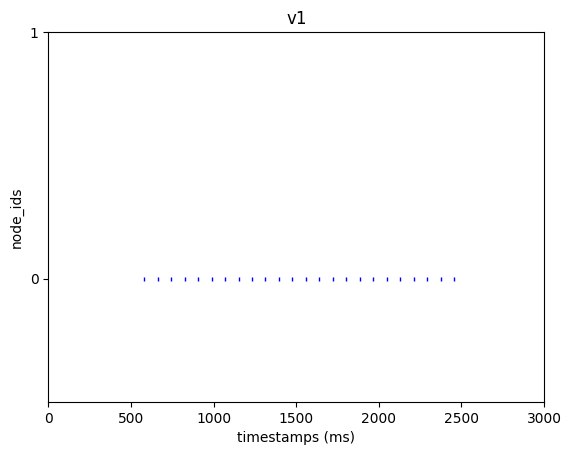

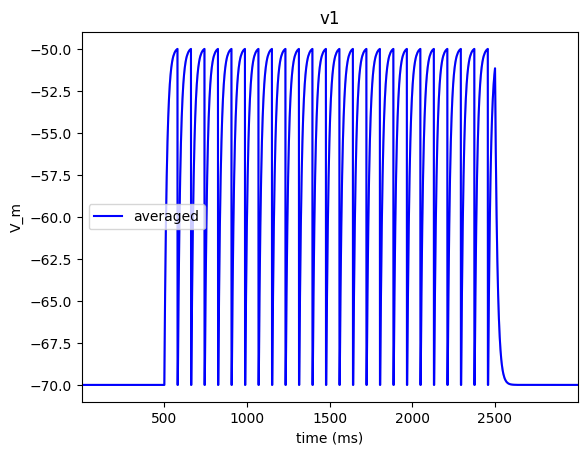

Re-run complete


In [9]:
updated_params = dict(pop._parameters["nest_params"])
updated_params.update({"V_th": -50.0, "tau_m": 15.0})

pop.configure(nest_params=updated_params)
clamp.configure(amp_na=335.)
cfg.configure(config_file="config_strong.json")

for node in workflow.nodes.values():
    node._context["results_path"] = "./results/run2"

ok = workflow.execute()
assert ok, "Re-run failed"
print("Re-run complete")


## 6. Increase the size of the population and re-run

Executing node: IClamp
Executing node: Population
Executing node: SimConfig
2026-06-17 14:20:12,354 [INFO] Created log file


INFO:NestIOUtils:Created log file


2026-06-17 14:20:12,362 [INFO] Batch processing nodes for v1/0.


INFO:NestIOUtils:Batch processing nodes for v1/0.


2026-06-17 14:20:12,363 [INFO] Setting up output directory


...

2026-06-17 14:20:13,363 [INFO] Simulation finished, finalizing results.


INFO:NestIOUtils:Simulation finished, finalizing results.


2026-06-17 14:20:13,653 [INFO] Done.


INFO:NestIOUtils:Done.


Executing node: Analysis


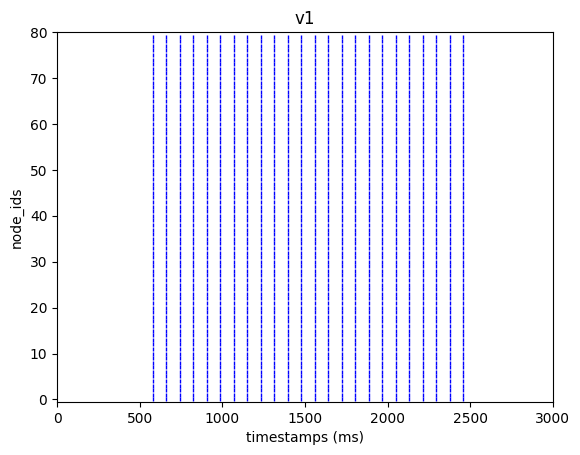

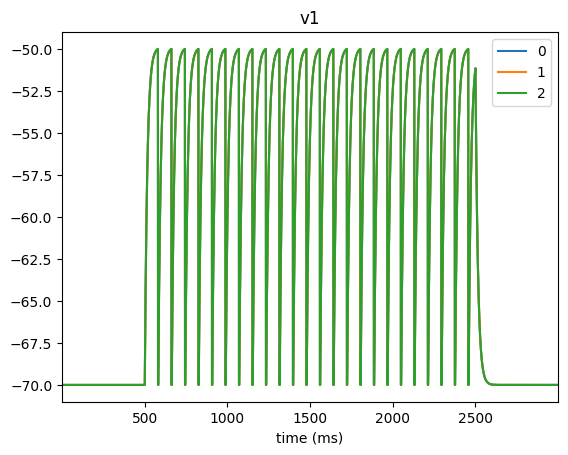

Re-run complete


In [10]:
pop.configure(N=80)
cfg.configure(config_file="config_pop.json")
ana.configure(trace_node_ids=[0, 1, 2])

for node in workflow.nodes.values():
    node._context["results_path"] = "./results/run3"

ok = workflow.execute()
assert ok, "Re-run failed"
print("Re-run complete")